# Simulated Annealing Experiments

### Imports and Basic Setup

In [1]:
from simulated_annealing import *
from data_generator import *
from data_loader import *
from annealing_helpers import *
import matplotlib.pyplot as plt
import os
import numpy as np

# Generate and load data
stops = 5
time_windows = 24
generate_dummy_data(stops, time_windows)
P, W = load_data_as_matrices("data/input/travel_times.csv", stops, time_windows)

# Base problem parameters
C = 40
R = 30
ALPHA = 1.0
BETA = 30.0
data = build_problem_data(P, C, R, alpha=ALPHA, beta=BETA)


### Base parameters for Annealing

In [2]:
base_initial_temp = 10.0
base_min_temp = 1e-3
base_cooling_rate = 0.999
max_iter = 2000
log_every = 1


### Experiment 1: Varying Initial Temperature

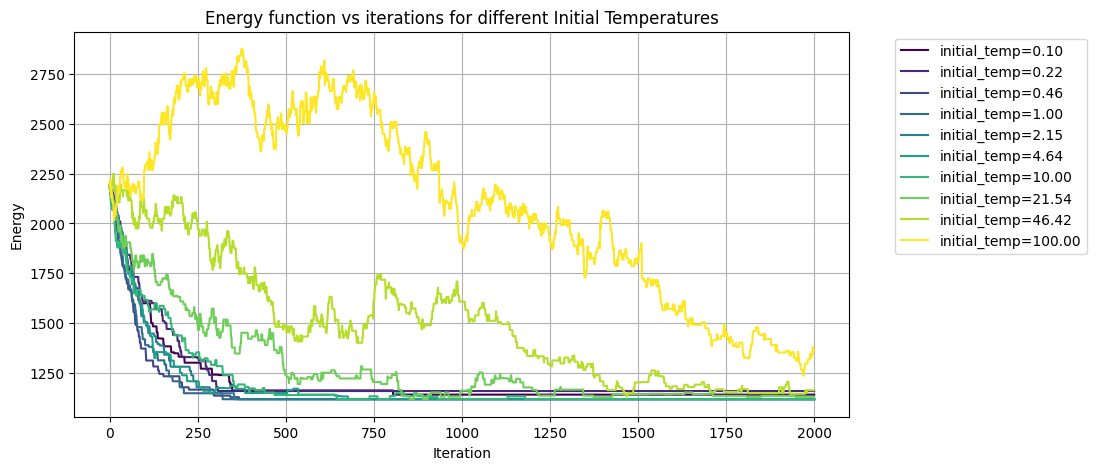

Final energies for different initial temperatures:
initial_temp: 0.10 | Final Energy: 1142.00
initial_temp: 0.22 | Final Energy: 1160.00
initial_temp: 0.46 | Final Energy: 1119.00
initial_temp: 1.00 | Final Energy: 1119.00
initial_temp: 2.15 | Final Energy: 1119.00
initial_temp: 4.64 | Final Energy: 1120.00
initial_temp: 10.00 | Final Energy: 1119.00
initial_temp: 21.54 | Final Energy: 1120.00
initial_temp: 46.42 | Final Energy: 1135.00
initial_temp: 100.00 | Final Energy: 1237.00


In [3]:
initial_temps = np.logspace(-1, 2, 10)

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(initial_temps)))
final_results_1 = []

for idx, temp in enumerate(initial_temps):
    results = run_schedule_optimization(
        data,
        initial_temp=temp,
        min_temp=base_min_temp,
        cooling_rate=base_cooling_rate,
        max_iter=max_iter,
        log_every=log_every
    )
    final_results_1.append((temp, results["best_solution"]["objective"]))
    xs, ys = zip(*results["log"])
    plt.plot(xs, ys, label=f'initial_temp={temp:.2f}', color=colors[idx])

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations for different Initial Temperatures')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
os.makedirs("experiment_charts", exist_ok=True)
plt.savefig("experiment_charts/exp1_initial_temp.png", bbox_inches='tight')
plt.show()

print("Final energies for different initial temperatures:")
for temp, en in final_results_1:
    print(f"initial_temp: {temp:.2f} | Final Energy: {en:.2f}")


### Experiment 2: Varying Minimum Temperature

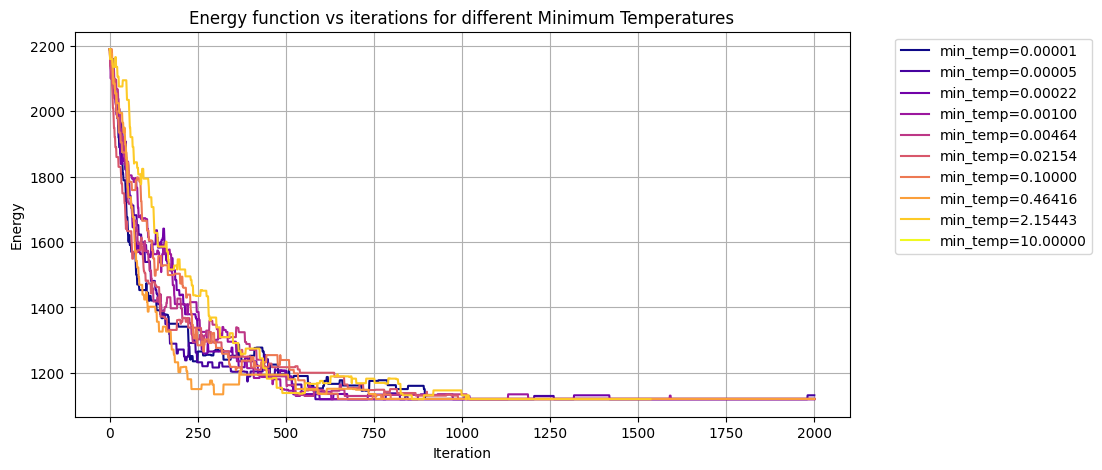

Final energies for different minimum temperatures:
min_temp: 0.00001 | Final Energy: 1120.00
min_temp: 0.00005 | Final Energy: 1119.00
min_temp: 0.00022 | Final Energy: 1119.00
min_temp: 0.00100 | Final Energy: 1119.00
min_temp: 0.00464 | Final Energy: 1119.00
min_temp: 0.02154 | Final Energy: 1120.00
min_temp: 0.10000 | Final Energy: 1120.00
min_temp: 0.46416 | Final Energy: 1120.00
min_temp: 2.15443 | Final Energy: 1119.00
min_temp: 10.00000 | Final Energy: 2190.00


In [4]:
min_temps = np.logspace(-5, 1, 10)

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('plasma')(np.linspace(0, 1, len(min_temps)))
final_results_2 = []

for idx, m_temp in enumerate(min_temps):
    results = run_schedule_optimization(
        data,
        initial_temp=base_initial_temp,
        min_temp=m_temp,
        cooling_rate=base_cooling_rate,
        max_iter=max_iter,
        log_every=log_every
    )
    final_results_2.append((m_temp, results["best_solution"]["objective"]))
    xs, ys = zip(*results["log"])
    plt.plot(xs, ys, label=f'min_temp={m_temp:.5f}', color=colors[idx])

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations for different Minimum Temperatures')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig("experiment_charts/exp2_min_temp.png", bbox_inches='tight')
plt.show()

print("Final energies for different minimum temperatures:")
for m_temp, en in final_results_2:
    print(f"min_temp: {m_temp:.5f} | Final Energy: {en:.2f}")


### Experiment 3: Varying Cooling Rate

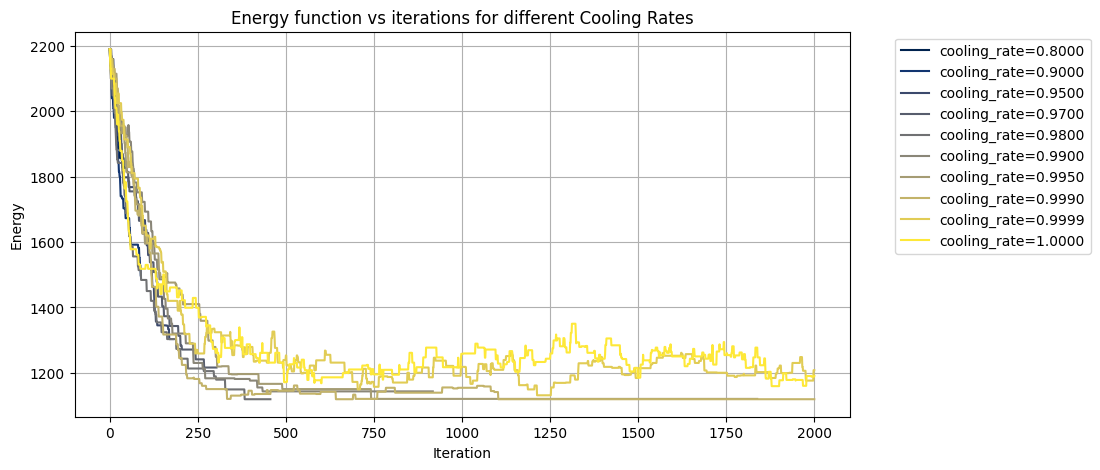

Final energies for different cooling rates:
cooling_rate: 0.8000 | Final Energy: 1827.00
cooling_rate: 0.9000 | Final Energy: 1498.00
cooling_rate: 0.9500 | Final Energy: 1303.00
cooling_rate: 0.9700 | Final Energy: 1216.00
cooling_rate: 0.9800 | Final Energy: 1119.00
cooling_rate: 0.9900 | Final Energy: 1143.00
cooling_rate: 0.9950 | Final Energy: 1120.00
cooling_rate: 0.9990 | Final Energy: 1119.00
cooling_rate: 0.9999 | Final Energy: 1131.00
cooling_rate: 1.0000 | Final Energy: 1159.00


In [5]:
cooling_rates = [0.80, 0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 1]

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('cividis')(np.linspace(0, 1, len(cooling_rates)))
final_results_3 = []

for idx, c_rate in enumerate(cooling_rates):
    results = run_schedule_optimization(
        data,
        initial_temp=base_initial_temp,
        min_temp=base_min_temp,
        cooling_rate=c_rate,
        max_iter=max_iter,
        log_every=log_every
    )
    final_results_3.append((c_rate, results["best_solution"]["objective"]))
    xs, ys = zip(*results["log"])
    plt.plot(xs, ys, label=f'cooling_rate={c_rate:.4f}', color=colors[idx])

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations for different Cooling Rates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig("experiment_charts/exp3_cooling_rate.png", bbox_inches='tight')
plt.show()

print("Final energies for different cooling rates:")
for c_rate, en in final_results_3:
    print(f"cooling_rate: {c_rate:.4f} | Final Energy: {en:.2f}")


### Experiment 4: Quick Grid Search

Running grid search over 125 combinations...


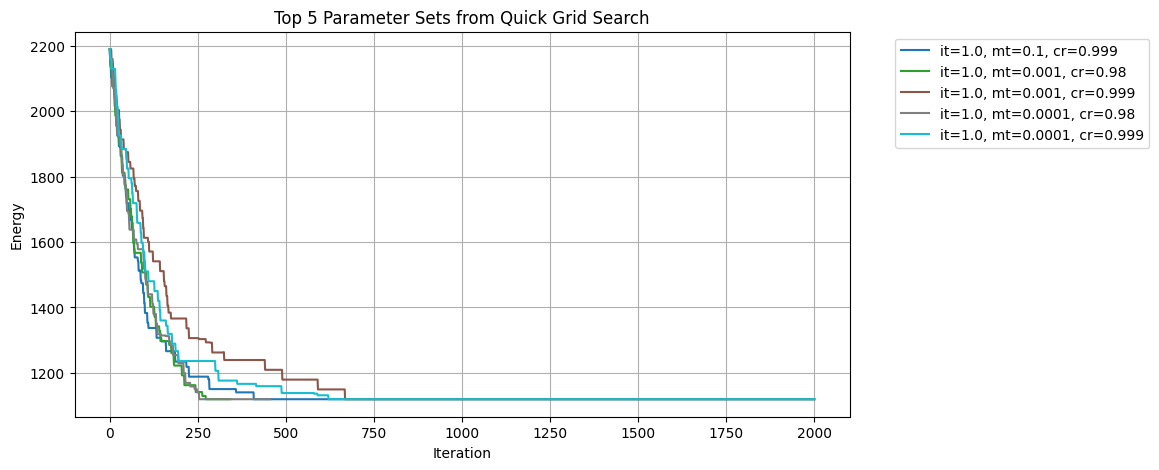

Top 5 parameters from Grid Search:
Rank 1: initial_temp=1.0, min_temp=0.1, cooling_rate=0.999 | Final Energy: 1119.00
Rank 2: initial_temp=1.0, min_temp=0.001, cooling_rate=0.98 | Final Energy: 1119.00
Rank 3: initial_temp=1.0, min_temp=0.001, cooling_rate=0.999 | Final Energy: 1119.00
Rank 4: initial_temp=1.0, min_temp=0.0001, cooling_rate=0.98 | Final Energy: 1119.00
Rank 5: initial_temp=1.0, min_temp=0.0001, cooling_rate=0.999 | Final Energy: 1119.00


In [6]:
import itertools

grid_initial_temps = [1.0, 2.0, 5.0, 10.0, 50.0]
grid_min_temps = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
grid_cooling_rates = [0.90, 0.95, 0.98, 0.99, 0.999]

grid_results = []
combinations = list(itertools.product(grid_initial_temps, grid_min_temps, grid_cooling_rates))
print(f"Running grid search over {len(combinations)} combinations...")

for it, mt, cr in combinations:
    res = run_schedule_optimization(
        data,
        initial_temp=it,
        min_temp=mt,
        cooling_rate=cr,
        max_iter=max_iter,
        log_every=log_every
    )
    # Safely extract best energy
    if "best_energy" in res:
        best_en = res["best_energy"]
    elif "best_solution" in res and "objective" in res["best_solution"]:
        best_en = res["best_solution"]["objective"]
    else:
        best_en = res["log"][-1][1]

    grid_results.append({
        "params": {"initial_temp": it, "min_temp": mt, "cooling_rate": cr},
        "best_energy": best_en,
        "log": res["log"]
    })

# Sort by best energy (lowest is best)
grid_results.sort(key=lambda x: x["best_energy"])
top_5 = grid_results[:5]

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(top_5)))

for idx, run in enumerate(top_5):
    p = run["params"]
    xs, ys = zip(*run["log"])
    label_str = f"it={p['initial_temp']}, mt={p['min_temp']}, cr={p['cooling_rate']}"
    plt.plot(xs, ys, label=label_str, color=colors[idx], linewidth=1.5)

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Top 5 Parameter Sets from Quick Grid Search')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig("experiment_charts/exp4_grid_search_top5.png", bbox_inches='tight')
plt.show()

print("Top 5 parameters from Grid Search:")
for idx, run in enumerate(top_5, 1):
    p = run["params"]
    print(f"Rank {idx}: initial_temp={p['initial_temp']}, min_temp={p['min_temp']}, cooling_rate={p['cooling_rate']} | Final Energy: {run['best_energy']:.2f}")


1 week cycle

In [7]:
# Generate and load data
stops = 5
time_windows = 168
generate_dummy_data(stops, time_windows)
P, W = load_data_as_matrices("data/input/travel_times.csv", stops, time_windows)

data = build_problem_data(P, C, R, alpha=ALPHA, beta=BETA)

max_iter = 5000

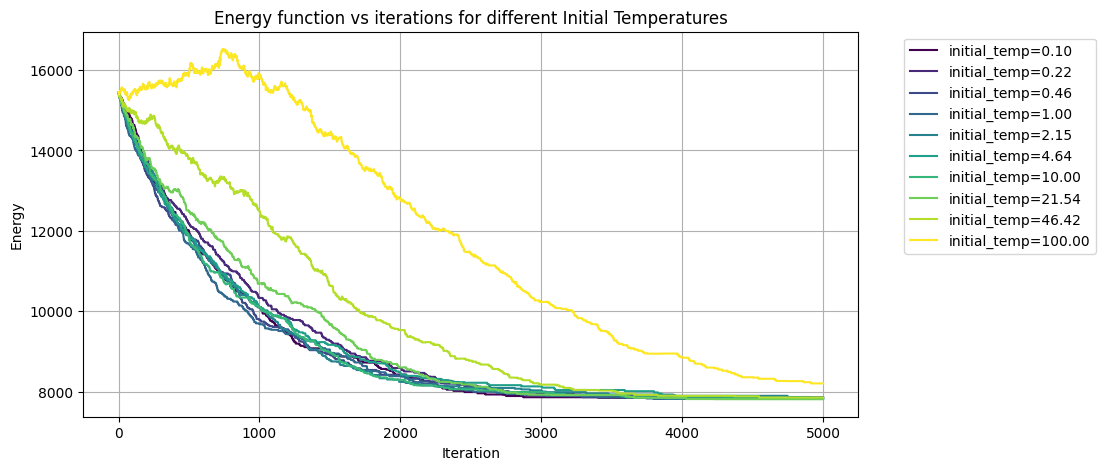

Final energies for different initial temperatures:
initial_temp: 0.10 | Final Energy: 7835.00
initial_temp: 0.22 | Final Energy: 7855.00
initial_temp: 0.46 | Final Energy: 7853.00
initial_temp: 1.00 | Final Energy: 7823.00
initial_temp: 2.15 | Final Energy: 7862.00
initial_temp: 4.64 | Final Energy: 7826.00
initial_temp: 10.00 | Final Energy: 7838.00
initial_temp: 21.54 | Final Energy: 7816.00
initial_temp: 46.42 | Final Energy: 7858.00
initial_temp: 100.00 | Final Energy: 8209.00


In [8]:
initial_temps = np.logspace(-1, 2, 10)

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(initial_temps)))
final_results_1 = []

for idx, temp in enumerate(initial_temps):
    results = run_schedule_optimization(
        data,
        initial_temp=temp,
        min_temp=base_min_temp,
        cooling_rate=base_cooling_rate,
        max_iter=max_iter,
        log_every=log_every
    )
    final_results_1.append((temp, results["best_solution"]["objective"]))
    xs, ys = zip(*results["log"])
    plt.plot(xs, ys, label=f'initial_temp={temp:.2f}', color=colors[idx])

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations for different Initial Temperatures')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
os.makedirs("experiment_charts", exist_ok=True)
plt.savefig("experiment_charts/exp1_initial_temp.png", bbox_inches='tight')
plt.show()

print("Final energies for different initial temperatures:")
for temp, en in final_results_1:
    print(f"initial_temp: {temp:.2f} | Final Energy: {en:.2f}")

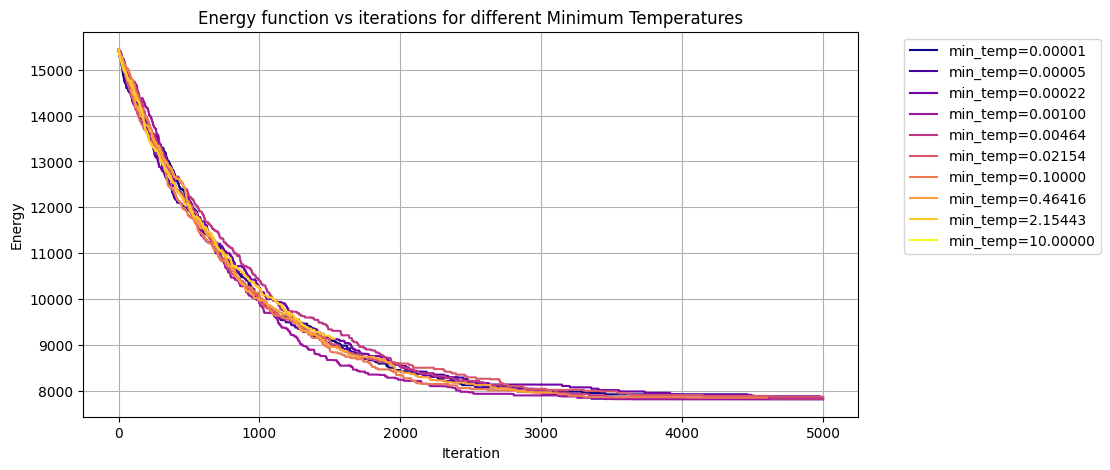

Final energies for different minimum temperatures:
min_temp: 0.00001 | Final Energy: 7857.00
min_temp: 0.00005 | Final Energy: 7812.00
min_temp: 0.00022 | Final Energy: 7846.00
min_temp: 0.00100 | Final Energy: 7811.00
min_temp: 0.00464 | Final Energy: 7819.00
min_temp: 0.02154 | Final Energy: 7865.00
min_temp: 0.10000 | Final Energy: 7844.00
min_temp: 0.46416 | Final Energy: 7961.00
min_temp: 2.15443 | Final Energy: 9133.00
min_temp: 10.00000 | Final Energy: 15450.00


In [9]:
min_temps = np.logspace(-5, 1, 10)

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('plasma')(np.linspace(0, 1, len(min_temps)))
final_results_2 = []

for idx, m_temp in enumerate(min_temps):
    results = run_schedule_optimization(
        data,
        initial_temp=base_initial_temp,
        min_temp=m_temp,
        cooling_rate=base_cooling_rate,
        max_iter=max_iter,
        log_every=log_every
    )
    final_results_2.append((m_temp, results["best_solution"]["objective"]))
    xs, ys = zip(*results["log"])
    plt.plot(xs, ys, label=f'min_temp={m_temp:.5f}', color=colors[idx])

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations for different Minimum Temperatures')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig("experiment_charts/exp2_min_temp.png", bbox_inches='tight')
plt.show()

print("Final energies for different minimum temperatures:")
for m_temp, en in final_results_2:
    print(f"min_temp: {m_temp:.5f} | Final Energy: {en:.2f}")


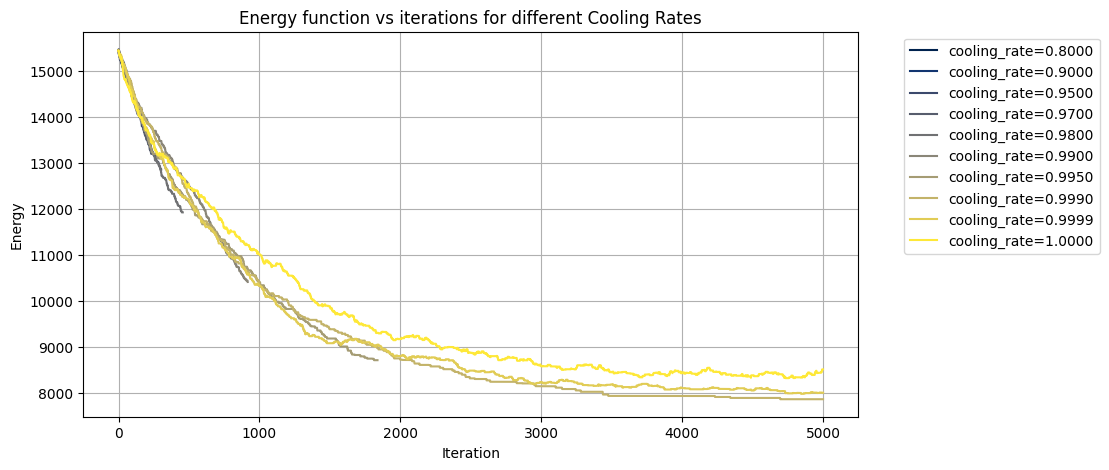

Final energies for different cooling rates:
cooling_rate: 0.8000 | Final Energy: 14945.00
cooling_rate: 0.9000 | Final Energy: 14572.00
cooling_rate: 0.9500 | Final Energy: 13718.00
cooling_rate: 0.9700 | Final Energy: 12857.00
cooling_rate: 0.9800 | Final Energy: 11927.00
cooling_rate: 0.9900 | Final Energy: 10411.00
cooling_rate: 0.9950 | Final Energy: 8708.00
cooling_rate: 0.9990 | Final Energy: 7858.00
cooling_rate: 0.9999 | Final Energy: 7975.00
cooling_rate: 1.0000 | Final Energy: 8317.00


In [10]:
cooling_rates = [0.80, 0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 1]

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('cividis')(np.linspace(0, 1, len(cooling_rates)))
final_results_3 = []

for idx, c_rate in enumerate(cooling_rates):
    results = run_schedule_optimization(
        data,
        initial_temp=base_initial_temp,
        min_temp=base_min_temp,
        cooling_rate=c_rate,
        max_iter=max_iter,
        log_every=log_every
    )
    final_results_3.append((c_rate, results["best_solution"]["objective"]))
    xs, ys = zip(*results["log"])
    plt.plot(xs, ys, label=f'cooling_rate={c_rate:.4f}', color=colors[idx])

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations for different Cooling Rates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig("experiment_charts/exp3_cooling_rate.png", bbox_inches='tight')
plt.show()

print("Final energies for different cooling rates:")
for c_rate, en in final_results_3:
    print(f"cooling_rate: {c_rate:.4f} | Final Energy: {en:.2f}")


Running grid search over 125 combinations...


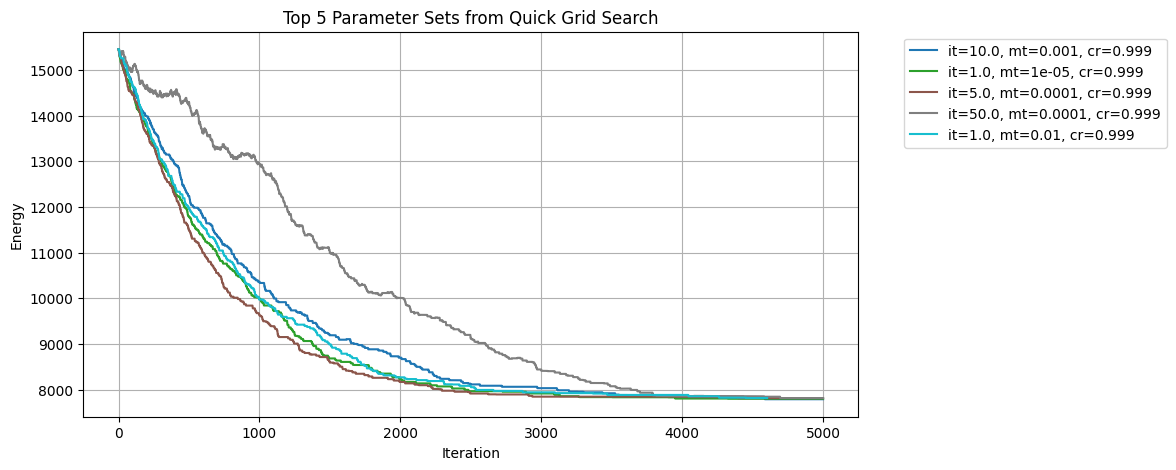

Top 5 parameters from Grid Search:
Rank 1: initial_temp=10.0, min_temp=0.001, cooling_rate=0.999 | Final Energy: 7794.00
Rank 2: initial_temp=1.0, min_temp=1e-05, cooling_rate=0.999 | Final Energy: 7804.00
Rank 3: initial_temp=5.0, min_temp=0.0001, cooling_rate=0.999 | Final Energy: 7818.00
Rank 4: initial_temp=50.0, min_temp=0.0001, cooling_rate=0.999 | Final Energy: 7819.00
Rank 5: initial_temp=1.0, min_temp=0.01, cooling_rate=0.999 | Final Energy: 7820.00


In [11]:
import itertools

grid_initial_temps = [1.0, 2.0, 5.0, 10.0, 50.0]
grid_min_temps = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
grid_cooling_rates = [0.90, 0.95, 0.98, 0.99, 0.999]

grid_results = []
combinations = list(itertools.product(grid_initial_temps, grid_min_temps, grid_cooling_rates))
print(f"Running grid search over {len(combinations)} combinations...")

for it, mt, cr in combinations:
    res = run_schedule_optimization(
        data,
        initial_temp=it,
        min_temp=mt,
        cooling_rate=cr,
        max_iter=max_iter,
        log_every=log_every
    )
    # Safely extract best energy
    if "best_energy" in res:
        best_en = res["best_energy"]
    elif "best_solution" in res and "objective" in res["best_solution"]:
        best_en = res["best_solution"]["objective"]
    else:
        best_en = res["log"][-1][1]

    grid_results.append({
        "params": {"initial_temp": it, "min_temp": mt, "cooling_rate": cr},
        "best_energy": best_en,
        "log": res["log"]
    })

# Sort by best energy (lowest is best)
grid_results.sort(key=lambda x: x["best_energy"])
top_5 = grid_results[:5]

plt.figure(figsize=(10, 5))
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(top_5)))

for idx, run in enumerate(top_5):
    p = run["params"]
    xs, ys = zip(*run["log"])
    label_str = f"it={p['initial_temp']}, mt={p['min_temp']}, cr={p['cooling_rate']}"
    plt.plot(xs, ys, label=label_str, color=colors[idx], linewidth=1.5)

plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Top 5 Parameter Sets from Quick Grid Search')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig("experiment_charts/exp4_grid_search_top5.png", bbox_inches='tight')
plt.show()

print("Top 5 parameters from Grid Search:")
for idx, run in enumerate(top_5, 1):
    p = run["params"]
    print(f"Rank {idx}: initial_temp={p['initial_temp']}, min_temp={p['min_temp']}, cooling_rate={p['cooling_rate']} | Final Energy: {run['best_energy']:.2f}")
